In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6FpXHU8mfKXE3GyycdRs")
project = rf.workspace("anish-tvmqt").project("pcb-inspection-3tb4t-kprkf")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 139.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pcb-inspection-1 in yolov11:: 100%|██████████| 866/866 [00:00<00:00, 8841.74it/s]


In [1]:
%pip install "ultralytics<=8.3.40"
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.5/112.6 GB disk)


In [2]:
from google.colab.patches import cv2_imshow


In [3]:
!yolo task=detect mode=train model=yolo11s.pt data=/content/pcb-inspection-1/data.yaml epochs=100 imgsz=640 plots=True

100% 18.4M/18.4M [00:00<00:00, 597MB/s]
New https://pypi.org/project/ultralytics/8.3.248 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/pcb-inspection-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

In [4]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/Screenshot 2026-01-06 194819.png: 640x640 2 ICs, 2 LEDs, 2 clocks, 5 connectors, 1 switch, 15.8ms
Speed: 3.0ms preprocess, 15.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


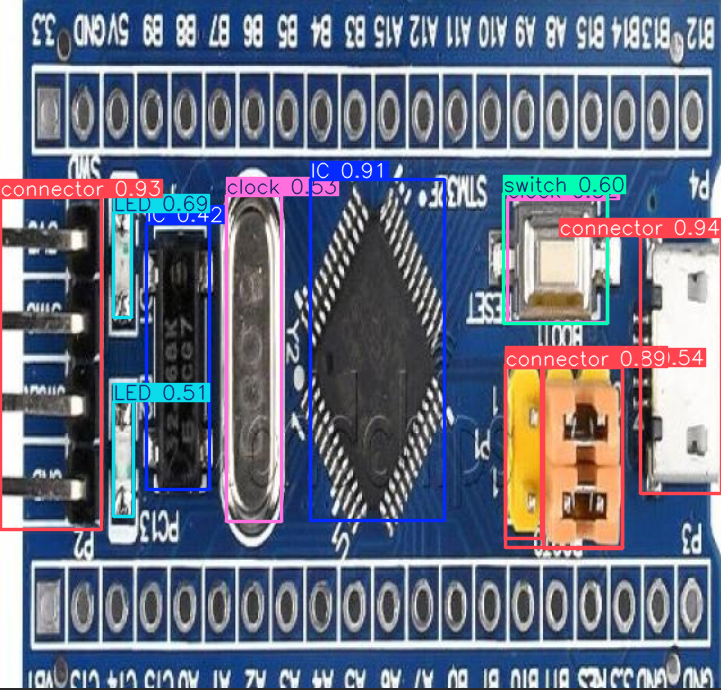

In [6]:
results = model("/content/Screenshot 2026-01-06 194819.png")

# get image with predictions
output = results[0].plot()

# show
cv2_imshow(output)

In [3]:
import cv2
import random
from ultralytics import YOLO

# -------- CONFIG --------
GOLDEN_IMG_PATH = "/content/Screenshot 2026-01-06 194819.png"
YOLO_WEIGHTS = "/content/best.pt"
NUM_COMPONENTS_TO_REMOVE = 2
# ------------------------

# Load image and model
img = cv2.imread(GOLDEN_IMG_PATH)
model = YOLO(YOLO_WEIGHTS)

# Detect components
results = model(img)[0]
boxes = []

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    boxes.append((x1, y1, x2, y2))

# Randomly select components to remove
remove_boxes = random.sample(boxes, min(NUM_COMPONENTS_TO_REMOVE, len(boxes)))

test_img = img.copy()

# Remove components (fill with background)
for (x1, y1, x2, y2) in remove_boxes:
    roi = test_img[y1:y2, x1:x2]
    mean_color = roi.mean(axis=(0,1)).astype(int)
    test_img[y1:y2, x1:x2] = mean_color

# Save test image
cv2.imwrite("test_pcb.jpg", test_img)

print("Test image created: test_pcb.jpg")



0: 640x640 2 ICs, 2 LEDs, 2 clocks, 5 connectors, 1 switch, 15.6ms
Speed: 18.3ms preprocess, 15.6ms inference, 239.7ms postprocess per image at shape (1, 3, 640, 640)
Test image created: test_pcb.jpg



0: 640x640 2 ICs, 2 LEDs, 2 clocks, 5 connectors, 1 switch, 15.6ms
Speed: 3.5ms preprocess, 15.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


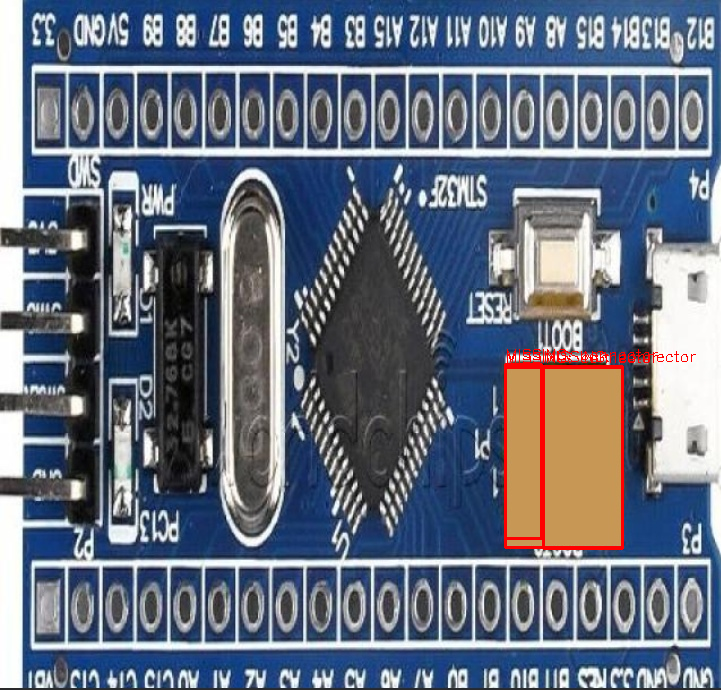

Missing components:
- connector (diff_ratio=0.62)
- connector (diff_ratio=0.65)
- connector (diff_ratio=0.54)


In [4]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# ---------------- CONFIG ----------------
GOLDEN_IMG_PATH = "/content/Screenshot 2026-01-06 194819.png"
YOLO_WEIGHTS    = "/content/best.pt"
TEST_IMG_PATH   = "/content/test_pcb.jpg"

BLUR_KERNEL = (5, 5)
DIFF_THRESHOLD = 30
DIFF_RATIO_THRESHOLD = 0.35
# ----------------------------------------

# Load YOLO model
model = YOLO(YOLO_WEIGHTS)
class_names = model.names

# Load images
golden_img = cv2.imread(GOLDEN_IMG_PATH)
test_img   = cv2.imread(TEST_IMG_PATH)

h, w, _ = golden_img.shape

# ---------- HOMOGRAPHY ALIGNMENT ----------
def align_images(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = matcher.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)[:200]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, _ = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
    aligned = cv2.warpPerspective(img2, H, (w, h))
    return aligned

aligned_test = align_images(golden_img, test_img)

# ---------- YOLO DETECTION ON GOLDEN ----------
results = model(golden_img)[0]
golden_boxes = []

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])
    golden_boxes.append((x1, y1, x2, y2, cls_id))

# ---------- MISSING COMPONENT DETECTION ----------
missing_boxes = []

for (x1, y1, x2, y2, cls_id) in golden_boxes:
    g_crop = golden_img[y1:y2, x1:x2]
    t_crop = aligned_test[y1:y2, x1:x2]

    if g_crop.size == 0 or t_crop.size == 0:
        continue

    g_gray = cv2.cvtColor(g_crop, cv2.COLOR_BGR2GRAY)
    t_gray = cv2.cvtColor(t_crop, cv2.COLOR_BGR2GRAY)

    g_blur = cv2.GaussianBlur(g_gray, BLUR_KERNEL, 0)
    t_blur = cv2.GaussianBlur(t_gray, BLUR_KERNEL, 0)

    diff = cv2.absdiff(g_blur, t_blur)
    _, th = cv2.threshold(diff, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)

    diff_ratio = np.sum(th > 0) / th.size

    if diff_ratio > DIFF_RATIO_THRESHOLD:
        missing_boxes.append((x1, y1, x2, y2, cls_id, diff_ratio))

# ---------- DRAW RESULTS ----------
output = test_img.copy()

for (x1, y1, x2, y2, cls_id, diff_ratio) in missing_boxes:
    label = f"MISSING: {class_names[cls_id]}"
    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(output, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

cv2_imshow(output)

# ---------- TEXT OUTPUT ----------
print("Missing components:")
for (_, _, _, _, cls_id, diff_ratio) in missing_boxes:
    print(f"- {class_names[cls_id]} (diff_ratio={diff_ratio:.2f})")
